## **Tesla stock price time-series analysis with RNNs**

### **Objective**
The objective of this exercise is to create a time series analysis Model using RNN variants, such as the LSTM and GRU using TensorFlow and Keras. I am testing this hypothesis: "Given the last N known closing prices, can the model predict the closing price of the next day?". Long-term dependencies are not captured here, as I will be using the following rules: the train/test splitting (90%/10%), window size (10) and forecast horizon (1 step). These can be modified in future experiments/models.

### **RNNs**
The **recurrent neural network**
is preferred to the vanilla neural network for this reason:
- Information loss; as data sequences get longer, the vanilla RNN loses information from previous inputs.

The vanilla NN is unable to learn from previous events well enough to predict the future. The RNNs have loops within its deep learning network to selectively retain information from previous inputs. The idea is that RNNs pass information from the previous state and current input to each new node in the network. Hence, they are most suited for sequential data.

### **LSTM (Long Short-Term Memory)**
A type of recurrent neural network (RNN) designed to handle sequences of data, especially when long-term dependencies are required. It is created to solve the **exploding/vanishing gradient problem**, a problem that during backpropagation, gradients can become too large/small that causes the model to deviate from the optimal solution/significantly slow down the training process.

A traditional RNN has a simple structure of input, hidden state and output. An LSTM rivals this better by having a more complex architecture, that is more memory cells and gates for selection of previous information.

LSTMs use three types of gates, namely
1. Forget Gate decides which information to selectively discard from the cell state. It controls the flow of information from the previous memory cell into the current memory cell.
2. Input Gate updates the memory with new information from the current input, controlled by multiplying the candidate cell state with a value from an activation function.
3. Output Gate determines what the next hidden state will be, which influences the output and a new hidden state (how much the updated trend affects the prediction). Another multiplicative operation takes place here with the updated cell state.

LSTMs also have memory cells instead of recurrent nodes to avoid vanishing/exploding gradients during backpropagation.



### **Initial analysis**

The dataset is analyzed and prepared for time series analysis.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# To standardize numerical features by scaling them
from sklearn.preprocessing import StandardScaler


data = pd.read_csv("TSLA.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2956 non-null   object 
 1   Open       2956 non-null   float64
 2   High       2956 non-null   float64
 3   Low        2956 non-null   float64
 4   Close      2956 non-null   float64
 5   Adj Close  2956 non-null   float64
 6   Volume     2956 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 161.8+ KB


In [ ]:
# Convert the Date column from an object type to a datetime type
data['Date'] = pd.to_datetime(data['Date'])

# Remove the adjusted close price column
data = data.drop(columns = "Adj Close")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2956 non-null   datetime64[ns]
 1   Open    2956 non-null   float64       
 2   High    2956 non-null   float64       
 3   Low     2956 non-null   float64       
 4   Close   2956 non-null   float64       
 5   Volume  2956 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 138.7 KB


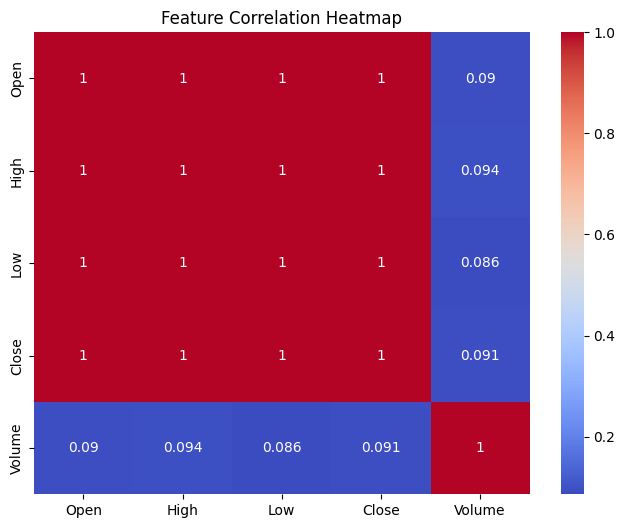

In [ ]:
# Check correlation between numerical columns
plt.figure(figsize=(8,6))
subset = data[['Open', 'High', 'Low', 'Close', 'Volume']]
sns.heatmap(subset.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

The heatmap shows that there is very strong correlation between the numerical features.

In [ ]:
# Get the start and end of the period
print(data['Date'][0])
print(data['Date'][len(data)-1])

2010-06-29 00:00:00
2022-03-24 00:00:00


<Axes: xlabel='Date'>

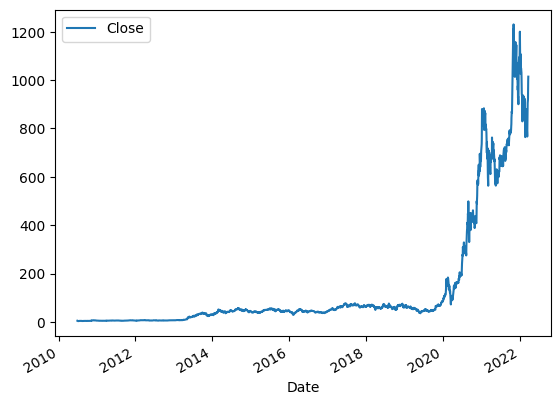

In [ ]:
# Plot the closing price against date
data.plot(x="Date", y="Close")

<Axes: xlabel='Date'>

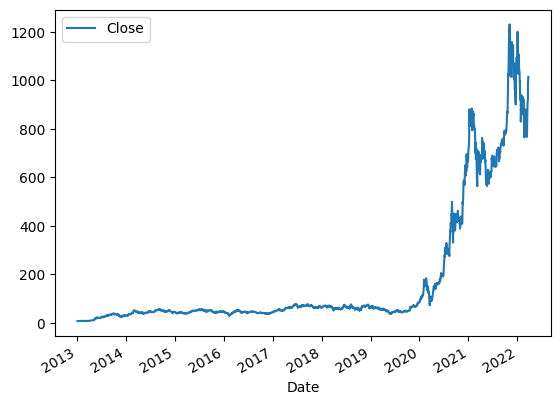

In [ ]:
# Remove data between 2010 and 2013 as nothing happened to the closing price
import datetime
data = data.loc[
    (data['Date'] >= '2013, 1, 1')
]

data.plot(x = "Date", y = "Close")

In [ ]:
# Prepare for analysis (predict the closing price, a key indicator of the performance of a stock)
data_close = data.filter(["Close"])

# Convert to a numpy array
data_closenp = data_close.values

# Training data is 90% of the data
# The test data is the remaining 10% (predicted/projected forecast)
train_len = int(np.ceil(len(data_closenp) * 0.90))

# Preprocessing stage (first to scale ONLY the train data)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_closenp)
# Obtain the training data as a 90% subset of the original data
training_data = scaled_data[:train_len]

X_train, y_train = [], []

# Create a sliding window over 10 days.
# For each window, the model predicts what is the
# price following the trend of closing price after 10 days.
for i in range(10, len(training_data)):
    X_train.append(training_data[i-10:i, 0])
    y_train.append(training_data[i, 0])

# Convert the lists to numpy arrays as TF only handles np arrays
X_train, y_train = np.array(X_train), np.array(y_train)

# Reshape to a 3D array/ reshape the data to 3 dimension
X_train = np.reshape(X_train, (X_train.shape[0],
                               X_train.shape[1], 1))

### **A basic stacked LSTM**

Instead of a single LSTM layer, create a stacked LSTM consisting of two LSTM layers followed by dense and dropout layers. In this context, one layer provides the following layer a sequential output. As there is no processing of categorical data (words in NLP), I will not be using any `keras.layers.Embedding` layer.

1. First layer: The initial layer is to understand patterns in the data. The LSTM layer has the following important arguments:
- The number of memory cells. The higher the number, the more complex patterns the model can capture; increasing the width of the model.
- `return_sequences` provides the full list of ideas for the next layer. If it is set to `True`, the next layer receives a sequence.
- `input_shape` tells the first layer what dimensions of data to expect

2. Second layer: Distills the important patterns from the first layer and prepares to make a final prediction. `return_sequences` is set to `False` to return the last output in the output sequence.

3. Dense layer: Turns complex patterns into a decision, while refining its understanding of the data to learn more complicated trends. A regular neural network layer with 128 neurons to make the final decision. The activation function is to introduce non-linearity to the data.

4. Dropout layer: Drops out a percentage of the neurons randomly during training to prevent overfitting (when the model memorizes the data too well but struggles with new data). Specifying a value of 0.5 keeps the model from being too sensitive to the training data and helps it perform better by randomly dropping 50% of the neurons.

5. Final dense layer: makes the final prediction. A layer with one neuron that outputs the prediction.

This is a basic LSTM model. Dense layers come after the hidden state. Customizations to the architecture could be explored such as increasing the number of LSTM layers (depth) or number of memory cells (width) for capturing more complex patterns.

### **Model compilation**
Compiles the model to tell it how to learn by configuring its training and evaluation.
- An optimizer to adjust its learning by updating the model's weights.
- The mean absolute error (MAE) is the loss function to indicate how far the model's predictions align with actual data. The optimizer seeks to minimize this loss during training.
- A configuration metric(s): Providing a list of metrics, or just one, for evaluation to judge the performance of the model, beyond the loss.

There are other optimizers, loss functions and metrics that can be considered other than the above.

In [ ]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

# Define the LSTM model
model = Sequential()

# Start building the model/stacking the layers
# First layer (LSTM)
model.add(LSTM(64, return_sequences=True,
                input_shape = (X_train.shape[1], 1)))

# Second layer (LSTM receiving from previous layer)
model.add(LSTM(64, return_sequences=False))

# Third layer (Dense: densely connected NN)
model.add(Dense(128, activation = 'relu'))

# Fourth layer (Dropout to prevent overfitting)
model.add(Dropout(0.5))

# Final output layer (Dense) with only 1 neuron to produce output
model.add(Dense(1))

# Display each layer of the model, showing the shape of each layer's
# output and the number of parameters in each layer
model.summary()

# Compile the model
model.compile(optimizer = "adam",
              loss = "mae",
              metrics = [keras.metrics.RootMeanSquaredError()])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# To train the model by fitting the data to it
# epochs: number of times the LSTM runs to find the best solution
# batch_size: amount of data that is in a batch when it runs
training = model.fit(X_train, y_train, epochs = 20, batch_size = 32)

# Prep the test data
test_data = scaled_data[train_len - 10:]
X_test, y_test = [], data_closenp[train_len:]

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0483 - root_mean_squared_error: 0.1090
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0422 - root_mean_squared_error: 0.0875
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0446 - root_mean_squared_error: 0.0954
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0447 - root_mean_squared_error: 0.1075
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0421 - root_mean_squared_error: 0.0938
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0414 - root_mean_squared_error: 0.0934
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0411 - root_mean_squared_error: 0.1010
Epoch 8/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0358 - root_mean_squared_error: 0.0894
Epoch 9/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0355 - root_mean_squared_error: 0.0883
Epoch 10/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0363 - root_mean_squared_error: 0.0866
Epoch 11

In [ ]:
# Using the same window approach for the test set
for i in range(10, len(test_data)):
    X_test.append(test_data[i-10:i, 0])

# Similarly, for the test set, convert to a 3D np array
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))


In [ ]:
# Make a prediction on the 10% test set
pred = model.predict(X_test)

# Downscale/revert back to the original scale for visualizing the predictions
pred = scaler.inverse_transform(pred)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


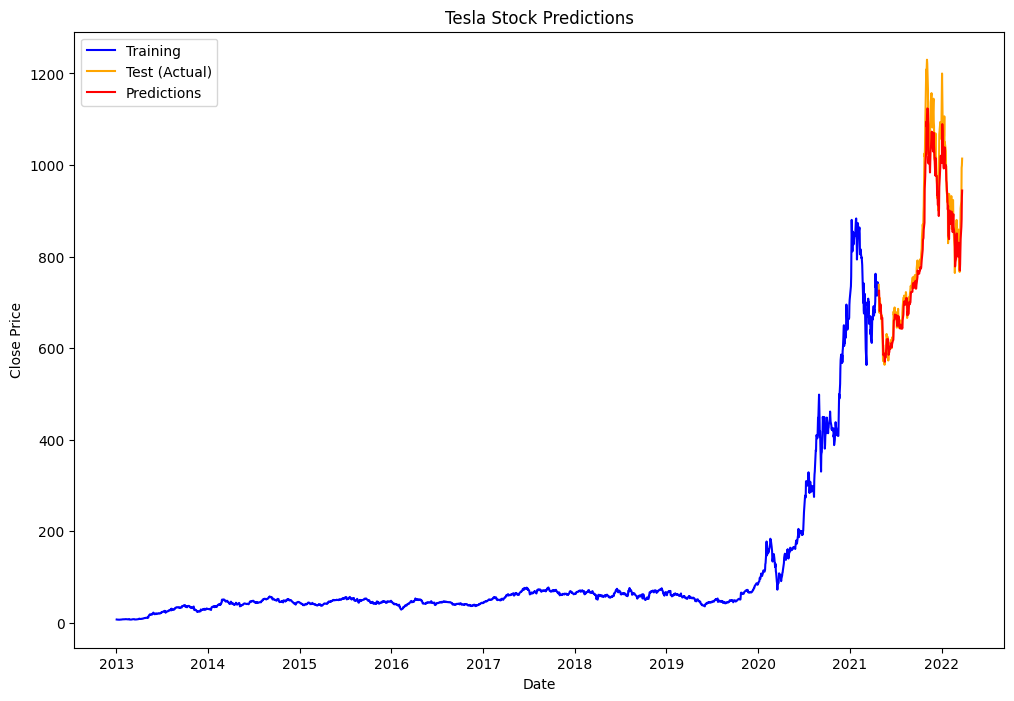

In [ ]:
# Plotting the visualization/showing the predicted against the actual
train = data[:train_len]
test = data[train_len:]
test = test.copy()

# Add a seperate column for the predictions
test['Predictions'] = pred
plt.figure(figsize=(12,8))
plt.plot(train['Date'], train['Close'], label="Training", color='blue')

# Plot actual vs prediction
plt.plot(test['Date'], test['Close'], label="Test (Actual)", color='orange')
plt.plot(test['Date'], test['Predictions'], label="Predictions", color='red')
plt.title("Tesla Stock Predictions")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()

In [ ]:
# Evaluation metric: Mean Absolute Error
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(test['Predictions'], test['Close'])
print(f"Mean Absolute Error (MAE): {mae}")

Mean Absolute Error (MAE): 32.22835092254849


From the mean absolute error and the plot, this LSTM model proves to be seemingly effective in predicting the next day's forecasted price following a window of 10 days. This window can be altered, adjusting the model's training.

### **Evaluation**
Improvements to performance can be explored by modifying the LSTM architecture as mentioned above, the model's compilation procedure, the number of epochs, the batch size and others.

### **Gated Recurrent Unit**
In this section, the same dataset will be trained and tested using the GRU. The GRU is a simpler version of the LSTM; it has a simpler architecture and thus, fewer parameters to train, making it computationally cheaper and faster. Just like LSTMs, GRUs model sequential data as they selectively keep and discard information over time.

GRUs do not have a memory cell state and 3 gates like in the LSTM, instead they have a "hidden state" and two gates. Hence, GRUs have fewer parameters which we will verify later.
- The reset gate is just like the forget gate in LSTM, limiting the flow of information from the previous state. This gate captures short-term dependencies in sequences.
- The update gate determines how much of the old state is copied over to the new state. This gate captures long-term dependencies.

The GRU model below is built similarly; two GRU layers, followed by a dense layer, a dropout layer and an output layer.

In [ ]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import GRU, Dense, Dropout

model_gru = Sequential()

# Add first GRU layer, followed by a second GRU layer
model_gru.add(GRU(64, return_sequences=True,
                  input_shape = (X_train.shape[1], 1)))
model_gru.add(GRU(64, return_sequences = False))

# fully connected nn
model_gru.add(Dense(128, activation = 'relu'))

# Fourth layer, add dropout
model_gru.add(Dropout(0.5))

# Final output layer (Dense) with only 1 neuron to produce output
model_gru.add(Dense(1))

# Display each layer of the model, showing the shape of each layer's
# output and the number of parameters in each layer
model_gru.summary()

# Compile the model
model_gru.compile(optimizer = "adam",
              loss = "mae",
              metrics = [keras.metrics.RootMeanSquaredError()])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 10, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,273 (180.75 KB)

 Trainable params: 46,273 (180.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
training_gru = model_gru.fit(X_train, y_train, epochs = 20, batch_size = 32)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2228 - root_mean_squared_error: 0.3180
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0744 - root_mean_squared_error: 0.1127
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0774 - root_mean_squared_error: 0.1289
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0666 - root_mean_squared_error: 0.1075
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0629 - root_mean_squared_error: 0.0967
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0614 - root_mean_squared_error: 0.1050
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0612 - root_mean_squared_error: 0.1083
Epoch 8/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0684 - root_mean_squared_error: 0.1237
Epoch 9/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0596 - root_mean_squared_error: 0.1017
Epoch 10/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0568 - root_mean_squared_error: 0.0976
Epoch 11

In [ ]:
# Make a prediction on the 10% test set
pred_gru = model_gru.predict(X_test)

# Downscale/revert back to the original scale for visualizing the predictions
pred_gru = scaler.inverse_transform(pred_gru)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


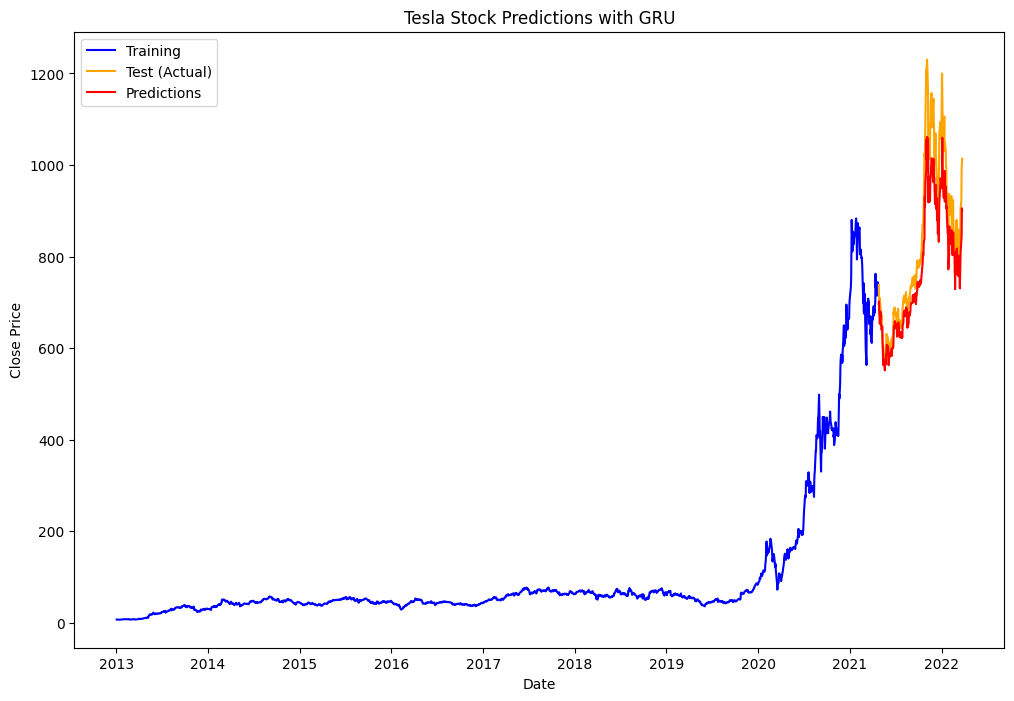

In [ ]:
# Plotting the visualization/showing the predicted against the actual
train = data[:train_len]
test = data[train_len:]
test = test.copy()

# Add a seperate column for the predictions
test['Predictions'] = pred_gru
plt.figure(figsize=(12,8))
plt.plot(train['Date'], train['Close'], label="Training", color='blue')

# Plot actual vs prediction
plt.plot(test['Date'], test['Close'], label="Test (Actual)", color='orange')
plt.plot(test['Date'], test['Predictions'], label="Predictions", color='red')
plt.title("Tesla Stock Predictions with GRU")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()

In [ ]:
# Evaluation metric: Mean Absolute Error to be used
# Placing predictions and actual side by side, compute the MAE
from sklearn.metrics import mean_absolute_error
mae_gru = mean_absolute_error(test['Predictions'], test['Close'])
print(f"Mean Absolute Error (MAE): {mae_gru}")

Mean Absolute Error (MAE): 59.544841878838895


## **LSTM vs GRU**

From the above results, one can conclude that the GRU model performs worse than the LSTM model at forecasting a time series, based off the plots and the mean absolute errors taken from both model evaluations.

The reason is likely due to the fact that the GRU is simpler than an LSTM, and that simplicity costs the GRU accuracy when the time series has complex dependencies.



### **LSTM variants**

As mentioned above, the model architecture and testing procedure can be modified.